# CBA 2026 SHAP Analysis — Global Landscape (publication-quality rebuild)

Selected +CNV MOSA run: `20260505_131645`.

This notebook is a publication-quality rebuild of the original `cba2026/01_global_shap_landscape.ipynb`. Every figure is generated by a function in `_shap_analysis.py` and uses the project `_plot_style` helpers (Okabe-Ito-derived palette, three Nature type scales, 300 dpi PNG and editable Type-42 PDF, frameless legends, no top/right spines). Output is written to `reports/cba2026_claude/shap_analysis/20260505_131645/`.

**Coverage**
- **Fig 1 — Global landscape composite** (replaces original Figs 1+2): omic-layer mean |SHAP|, within-family share, top-25 features per family.
- **Fig 2 — Top-feature heatmap** (replaces original Fig 3) with a dedicated omic-layer swatch column so feature labels never overlap.
- **Fig 3 — Target-level omic composition** (replaces original Fig 4) with violin + strip + median bar.
- **Fig 8 — SHAP concentration curves** (new) — per-target Lorenz-style cumulative SHAP, family-stratified.
- Copy-number tables (`table_global_copynumber_feature_ranking`, `table_copynumber_feature_frequency_top200`, `table_target_copynumber_share_top200`).


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd()))
import _shap_analysis as shap_an

print(f"ROOT     = {shap_an.ROOT}")
print(f"FIG_DIR  = {shap_an.FIG_DIR}")

ROOT     = /mnt/scratch/scai/PhenPredCCMA
FIG_DIR  = /mnt/scratch/scai/PhenPredCCMA/reports/cba2026_claude/shap_analysis/20260505_131645


## Load SHAP tables

Loads the per-family feature rank, omic rank and top-200 feather files. The runner exports mean-absolute SHAP only (the `_mean_abs` suffix), and we keep the union as both per-family dicts and concatenated frames for downstream summaries.


In [2]:
tables = shap_an.load_shap_tables()
summary = (
    tables["omic_rank_all"]
    .groupby("target_label", as_index=False)
    .agg(omic_layers=("omic_layer", "nunique"),
         total_importance=("importance", "sum"))
)
summary["top_features_rows"] = [tables["top_features"][f].shape[0]
                                 for f in shap_an.TARGET_META]
summary["unique_targets"] = [tables["top_features"][f]["target_name"].nunique()
                              for f in shap_an.TARGET_META]
summary

,target_label,omic_layers,total_importance,top_features_rows,unique_targets
0,CRISPR-Cas9,5,0.000540,100000,500
1,Drug response,6,0.001224,100000,500


## Figure 1 — Global landscape composite

Four-panel composite using `gridspec` for unequal row heights:
- **(a)** Mean absolute SHAP per omic layer, family-paired bars (×10⁻³ on the axis directly so no offset text needs to dodge the legend).
- **(b)** Within-family share, expressed as a percentage so the two families are directly comparable.
- **(c, d)** Top-25 globally ranked features per family, bars coloured by omic layer with a single shared legend at the bottom.


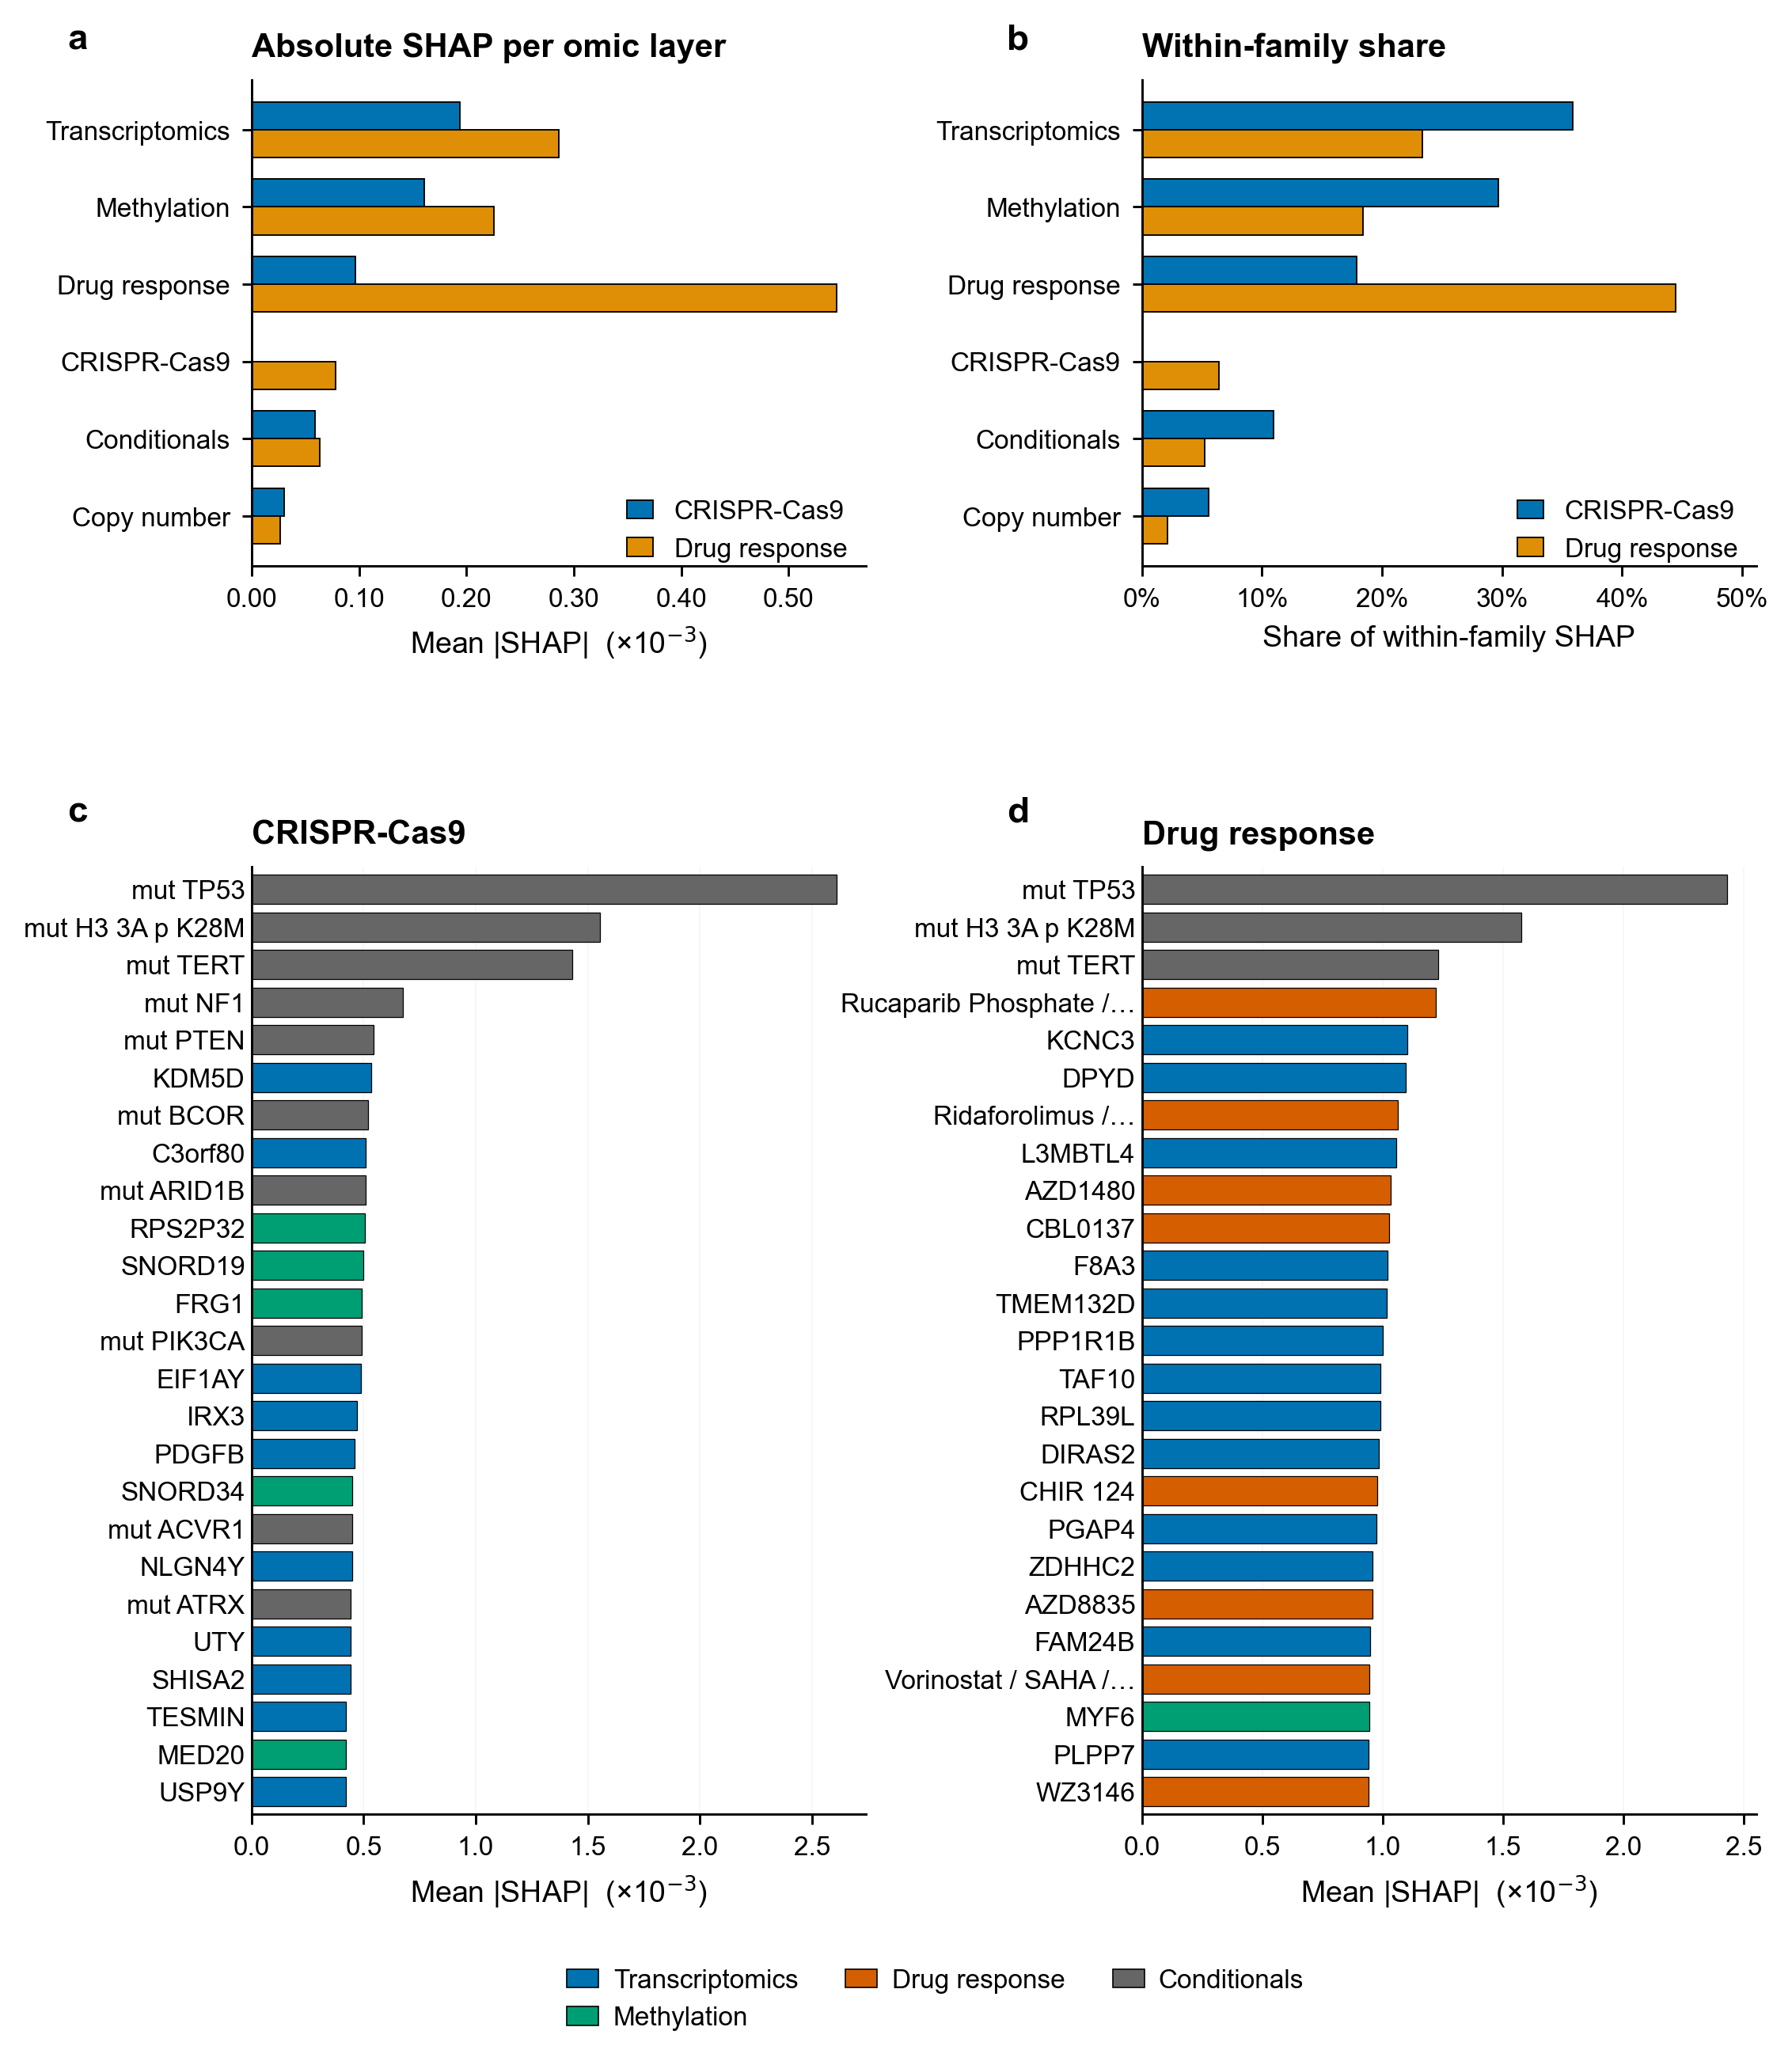

In [3]:
fig1_pdf = shap_an.fig1_global_landscape(tables)
display(Image(filename=str(fig1_pdf.with_suffix(".png")), embed=True))

## Figure 2 — Top global feature heatmap

Feature × family heatmap using the union of the top-25 ranked features per family. The y-axis carries an omic-layer colour swatch in a *separate* axis — that prevents the swatches from clipping the feature labels (a recurring problem in the original notebook). Colour bar is on a dedicated axis to the right of the heatmap.


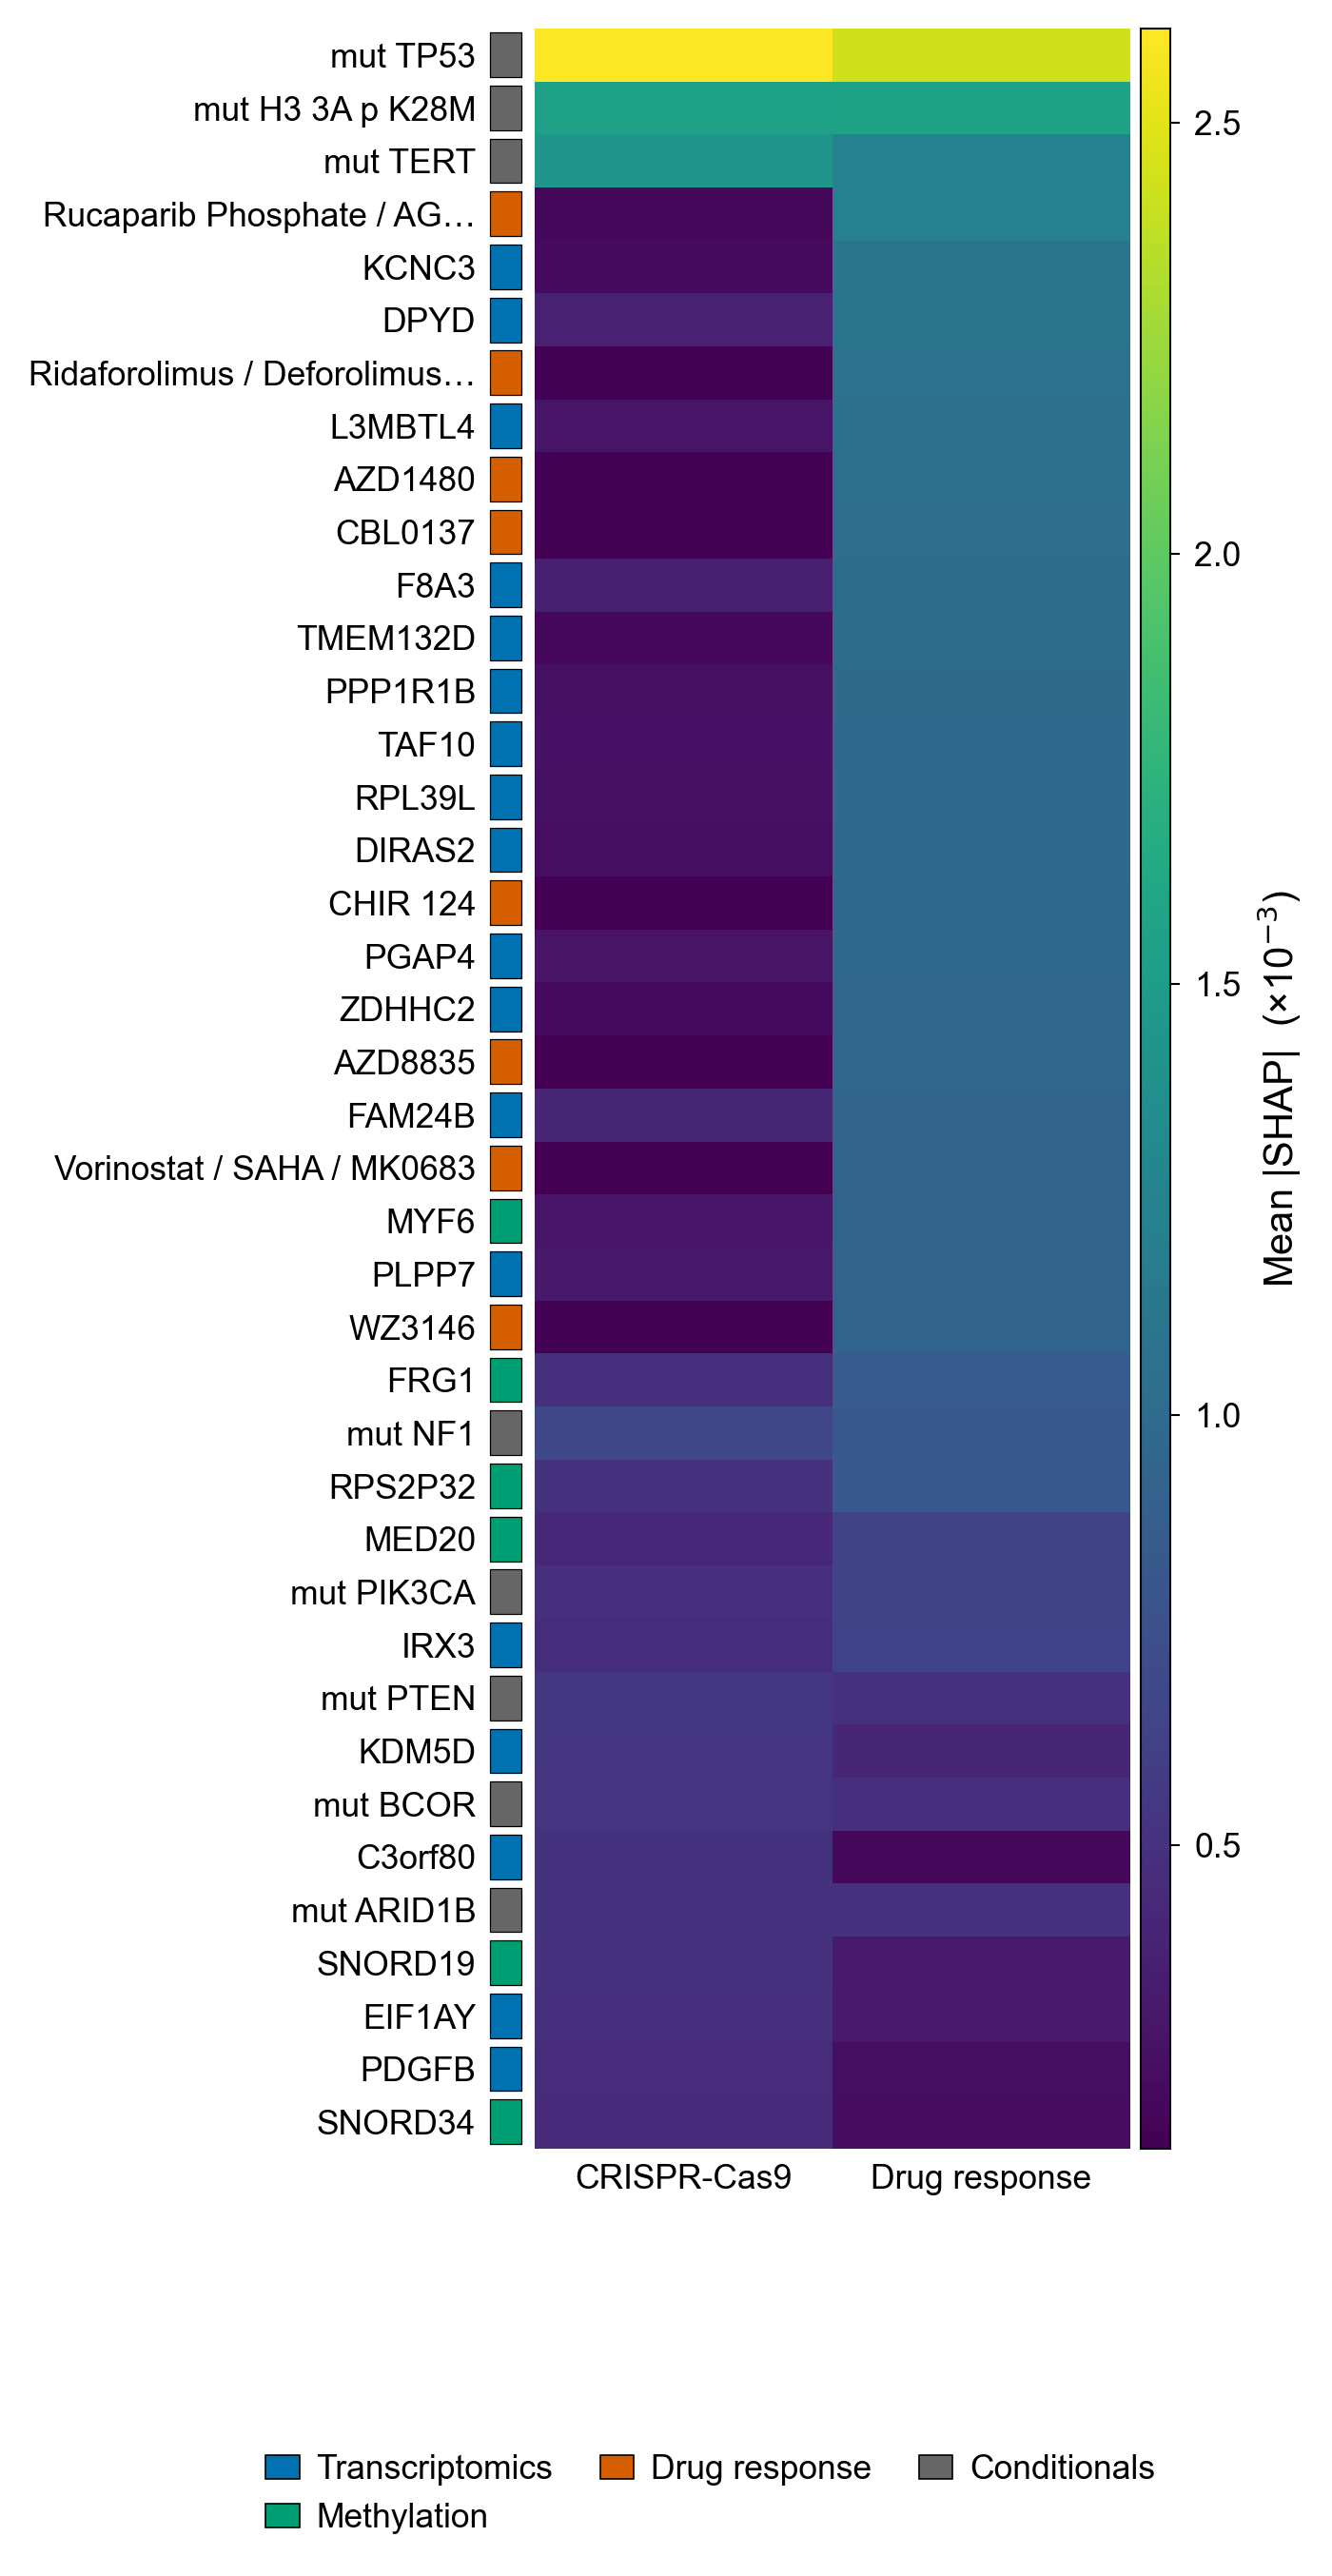

In [4]:
fig2_pdf = shap_an.fig2_global_feature_heatmap(tables)
display(Image(filename=str(fig2_pdf.with_suffix(".png")), embed=True))

## Figure 3 — Target-level omic composition

For each target we compute the share of top-200 SHAP that each omic layer accounts for. The violin shows the per-target distribution; jittered points expose the long tails; a vertical bar marks the per-layer median. Layout reserves a dedicated bottom margin for the explanatory caption so it never lands on the data.


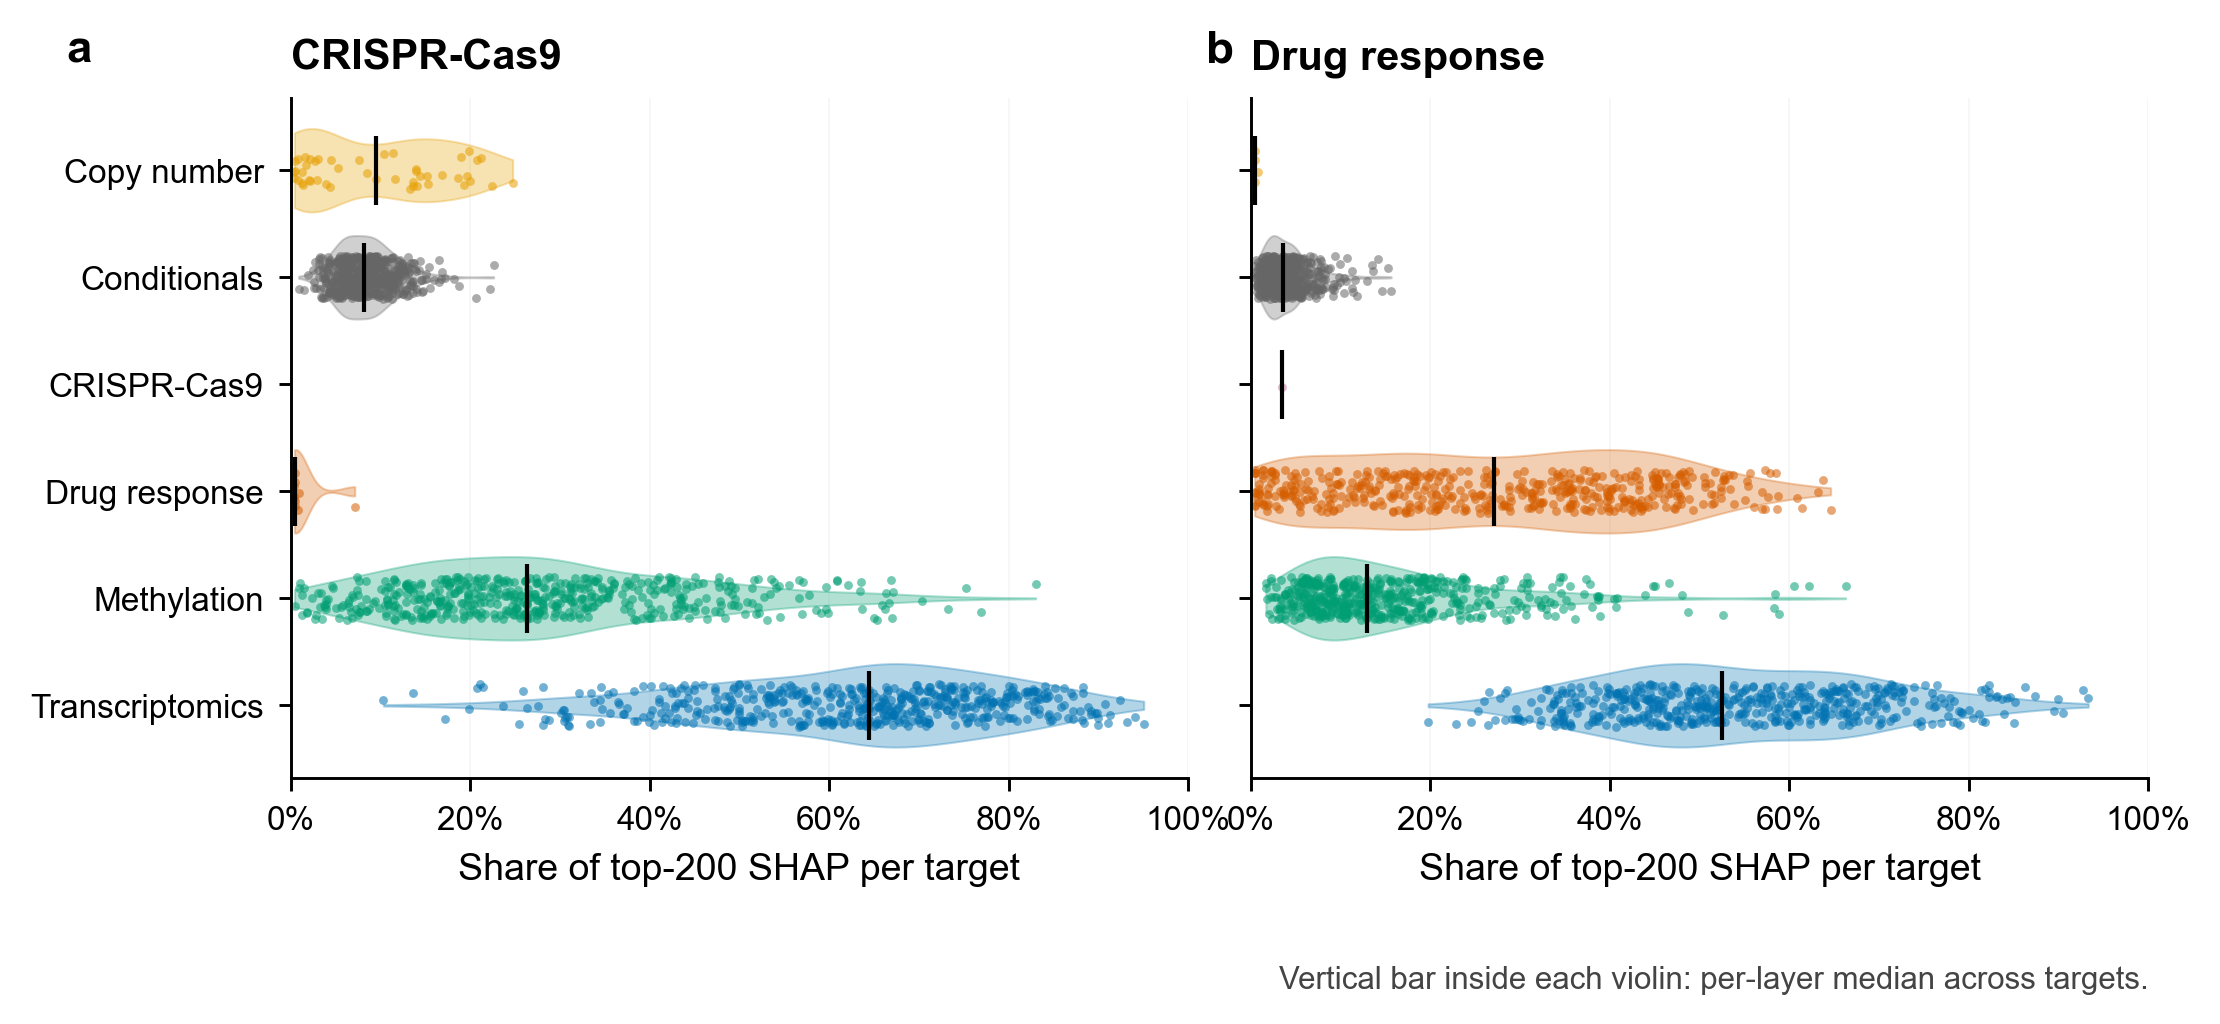

In [5]:
fig3_pdf = shap_an.fig3_target_omic_composition(tables)
display(Image(filename=str(fig3_pdf.with_suffix(".png")), embed=True))

## Figure 8 — SHAP concentration curves (new)

Cumulative-share-of-top-200-SHAP versus feature rank, per target family. The bold line is the per-target median; the dashed lines / band are the 10th and 90th percentiles. A red marker at rank 10 calls out how much SHAP mass is captured in the head of the ranking — a useful complement to the global rankings above because it tells us how 'spread' attribution actually is for a typical target.


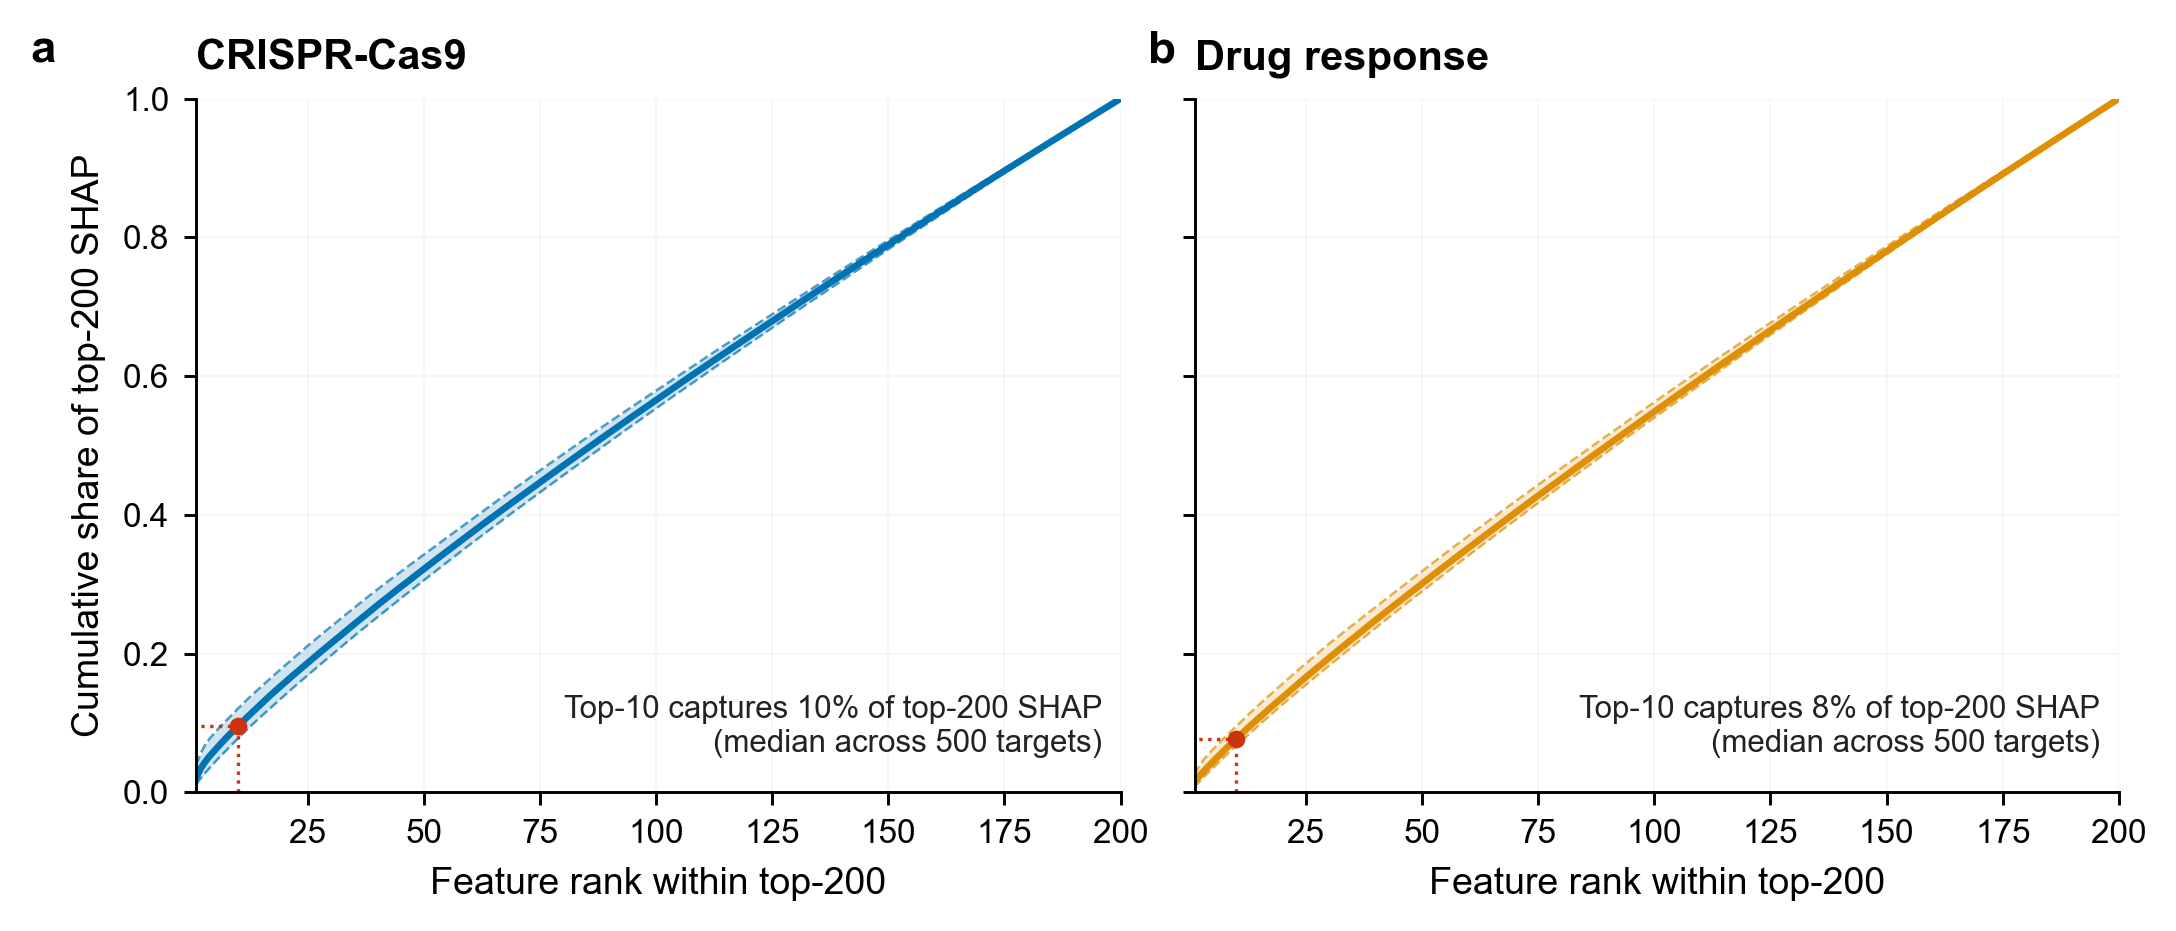

In [6]:
fig8_pdf = shap_an.fig8_shap_concentration(tables)
display(Image(filename=str(fig8_pdf.with_suffix(".png")), embed=True))

## Copy-number signal tables

Three CSVs make the +CNV contribution easy to inspect. They duplicate the originals' content but are derived through the shared analysis module so we have a single source of truth.


In [7]:
import pandas as pd

performance = shap_an.load_performance()
analysis = shap_an.assemble_analysis_table(tables, performance)
table_paths = shap_an.write_tables(tables, analysis)
for name, path in table_paths.items():
    print(f"{name}: {path.relative_to(shap_an.ROOT)}")
print()
cnv_global = pd.read_csv(table_paths["table_global_copynumber_feature_ranking"])
cnv_global.head(10)

table_global_copynumber_feature_ranking: reports/cba2026_claude/shap_analysis/20260505_131645/table_global_copynumber_feature_ranking.csv
table_copynumber_feature_frequency_top200: reports/cba2026_claude/shap_analysis/20260505_131645/table_copynumber_feature_frequency_top200.csv
table_target_copynumber_share_top200: reports/cba2026_claude/shap_analysis/20260505_131645/table_target_copynumber_share_top200.csv
target_level_shap_performance_summary: reports/cba2026_claude/shap_analysis/20260505_131645/target_level_shap_performance_summary.csv
targets_high_copynumber_shap_share: reports/cba2026_claude/shap_analysis/20260505_131645/targets_high_copynumber_shap_share.csv
targets_top_gain_loss_vs_rf_baseline: reports/cba2026_claude/shap_analysis/20260505_131645/targets_top_gain_loss_vs_rf_baseline.csv



,feature,importance,omic_layer,target_family,target_label
0,copynumber_MED12,0.000248,copynumber,crisprcas9,CRISPR-Cas9
1,copynumber_IRAK1,0.000236,copynumber,crisprcas9,CRISPR-Cas9
2,copynumber_BCOR,0.000233,copynumber,crisprcas9,CRISPR-Cas9
3,copynumber_RBM10,0.000232,copynumber,crisprcas9,CRISPR-Cas9
4,copynumber_P2RY8,0.000229,copynumber,crisprcas9,CRISPR-Cas9
5,copynumber_WAS,0.000219,copynumber,crisprcas9,CRISPR-Cas9
6,copynumber_ZRSR2,0.000215,copynumber,crisprcas9,CRISPR-Cas9
7,copynumber_ATRX,0.000213,copynumber,crisprcas9,CRISPR-Cas9
8,copynumber_IRS4,0.000212,copynumber,crisprcas9,CRISPR-Cas9
9,copynumber_ATP2B3,0.000210,copynumber,crisprcas9,CRISPR-Cas9


In [8]:
cnv_hits = pd.read_csv(table_paths["table_copynumber_feature_frequency_top200"])
cnv_hits.head(10)

,target_family,target_label,omics_feature,n_targets,mean_importance,max_importance
0,crisprcas9,CRISPR-Cas9,copynumber_MED12,45,0.000624,0.000980
1,crisprcas9,CRISPR-Cas9,copynumber_IRAK1,40,0.000601,0.000934
2,crisprcas9,CRISPR-Cas9,copynumber_RBM10,40,0.000583,0.000928
3,crisprcas9,CRISPR-Cas9,copynumber_P2RY8,39,0.000583,0.000888
4,crisprcas9,CRISPR-Cas9,copynumber_BCOR,38,0.000596,0.000900
5,crisprcas9,CRISPR-Cas9,copynumber_ZRSR2,33,0.000551,0.000835
6,crisprcas9,CRISPR-Cas9,copynumber_WAS,31,0.000579,0.000874
7,crisprcas9,CRISPR-Cas9,copynumber_ATRX,29,0.000568,0.000866
8,crisprcas9,CRISPR-Cas9,copynumber_RPS6KA3,28,0.000557,0.000822
9,crisprcas9,CRISPR-Cas9,copynumber_ATP2B3,28,0.000556,0.000828


## Output files


In [9]:
for path in sorted(shap_an.FIG_DIR.glob("fig*")):
    print(path.relative_to(shap_an.ROOT))
for path in sorted(shap_an.FIG_DIR.glob("table_*")):
    print(path.relative_to(shap_an.ROOT))

reports/cba2026_claude/shap_analysis/20260505_131645/fig1_global_landscape.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig1_global_landscape.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig2_global_feature_heatmap.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig2_global_feature_heatmap.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig3_target_omic_composition.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig3_target_omic_composition.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig4_performance_vs_profile.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig4_performance_vs_profile.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig5_selected_crispr_top_features.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig5_selected_crispr_top_features.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig6_selected_crispr_omic_composition.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/